Antes de entrenar los modelos debemos asegurarnos de:

| Paso                     | Qué hace                                                                                                      | Cuándo aplicarlo                                      |
| ------------------------ | ------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------- |
|  Revisión de nulos     | `df.isna().sum()`                                                                                             | Si alguna feature quedó con `NaN`, imputar o eliminar |
| Juntar features   | Unimos las features para processarlas adecuadamente. |
|  Escalado              | `StandardScaler`, `MinMaxScaler`                                                                              | Solo si usarás modelos lineales o redes               |
| Selección de features | Eliminar columnas con varianza cero o correlación extrema                                                     | Mejora velocidad y evita ruido                        |
| Balanceo de clases    | `SMOTE`, `class_weight` o undersampling                                                                       | Si la clase (`categoria_delito`) es muy desbalanceada |
| Encoding del target   | Si tu target es string (`delito de bajo impacto`, etc.), conviértelo a `LabelEncoder` o one-hot según modelo. |                                                       |


In [1]:
# Version actualizada de scikit-learn que permite aplicar peso de clases a las modelos

#!pip install -U scikit-learn==1.4.2


# **1. LIBRERIAS**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from scipy import sparse
from scipy.sparse import load_npz, hstack

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline

from sklearn.base import clone
from sklearn.metrics import accuracy_score, classification_report, f1_score, balanced_accuracy_score, roc_auc_score

import os, sys, math, gc, json
import joblib
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="The default value of `dual` will change")



# **2. CONFIGURACIÓN DEL AMBIENTE**


## 2.1 VARIABLES GLOBALES

In [3]:
# Semilla global para reproducibilidad
SEED = 42

# Le indicamos a Pandas que siempre muestre hasta 50 columnas completas en lugar de cortarlas con “...”.
pd.set_option("display.max_columns", 50)

In [4]:
FEATURE_FILES = {
    "temporal": ("train_feat_temporal.csv", "test_feat_temporal.csv"),
    "spatial": ("train_feat_spatial.csv", "test_feat_spatial.csv"),
    "institutional": ("train_feat_institutional.csv", "test_feat_institutional.csv"),
    "lag": ("train_feat_lag.csv", "test_feat_lag.csv"),
}

## 2.2 ACCESO A DATOS

In [5]:
# ---- Switch de entorno: "colab" o "local"
RUN_ENV = "local"   # <-- cambia a "local" si no usas Google Colab

# ---- Rutas base
if RUN_ENV.lower() == "colab":
    try:
        from google.colab import drive
        drive.mount("/drive")
    except Exception as e:
        print("Aviso: no se pudo montar Drive automáticamente:", e)
    # Ajusta esta ruta a tu carpeta del proyecto en Drive
    BASE_DIR = "/drive/My Drive/Colab Notebooks/reto-Thales/"
else:
    # Ajusta a tu ruta local del proyecto
    BASE_DIR = "/Users/jorgevalverde/Documents/myEnv/crimen-cdmx/"

os.makedirs(BASE_DIR, exist_ok=True)

# Ruta de los CSVs
X_TRAIN_PATH = os.path.join(BASE_DIR, "data", "train_split.csv")
X_TEST_PATH  = os.path.join(BASE_DIR, "data", "test_split.csv")
y_TRAIN_PATH = os.path.join(BASE_DIR, "data", "y_train.csv")
y_TEST_PATH  = os.path.join(BASE_DIR, "data", "y_test.csv")

# Guardar artefactos para inferencia ===
RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Entorno: {RUN_ENV} | BASE_DIR: {BASE_DIR}")

Entorno: local | BASE_DIR: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/


In [6]:
# Vamos utilizar un archivo de funciones propio
#sys.path.insert(0, BASE_DIR) #para acceder desde Colab-Drive
import myUtils as myUtils


# **3. LECTURA DE DATOS**


## Lectura de Clases

In [7]:
y_train = pd.read_csv(y_TRAIN_PATH)
y_train

,categoria_delito
0,delito de bajo impacto
1,delito de bajo impacto
2,robo a negocio con violencia
3,delito de bajo impacto
4,delito de bajo impacto
...,...
159766,robo a negocio con violencia
159767,delito de bajo impacto
159768,delito de bajo impacto
159769,delito de bajo impacto


In [8]:
y_test = pd.read_csv(y_TEST_PATH)
y_test

,categoria_delito
0,delito de bajo impacto
1,delito de bajo impacto
2,delito de bajo impacto
3,delito de bajo impacto
4,delito de bajo impacto
...,...
39938,delito de bajo impacto
39939,robo a transeunte en via publica con y sin vio...
39940,robo de vehiculo con y sin violencia
39941,robo de vehiculo con y sin violencia


In [9]:
# Aprovechamos y codificamos las clases
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)            # 0..K-1
y_test_enc = le.transform(y_test) 


In [10]:
n_classes = len(le.classes_)
print("Clases encoder:", list(le.classes_))

Clases encoder: ['delito de bajo impacto', 'hecho no delictivo', 'otras', 'robo a negocio con violencia', 'robo a transeunte en via publica con y sin violencia', 'robo de vehiculo con y sin violencia']


In [11]:
# Guardar LabelEncoder
encoder_path = os.path.join(RESULTS_DIR, "label_encoder_y.joblib")
joblib.dump(le, encoder_path)
print(f" LabelEncoder guardado en: {encoder_path}")

 LabelEncoder guardado en: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/label_encoder_y.joblib


## Lectura de Features

Lo que tenemos es:

| Bloque              | Archivo(s)                                                    | Tipo   |
| ------------------- | ------------------------------------------------------------- | ------ |
| Temporal            | `train_feat_temporal.csv`, `test_feat_temporal.csv`           | CSV    |
| Espacial            | `train_feat_espatial.csv`, `test_feat_espacial.csv`           | CSV    |
| Institucional       | `train_feat_institutional.csv`, `test_feat_institucional.csv` | CSV    |
| Coherencia temporal | `train_feat_lag.csv`, `test_feat_lag.csv`                     | CSV    |
| Textual (TF-IDF)    | `tfidf_delito_train.npz`, `tfidf_delito_test.npz`             | Sparse |


In [12]:
# Diccionarios de DataFrames
X_train_blocks = {}
X_test_blocks = {}

In [13]:
for name, (train_file, test_file) in FEATURE_FILES.items():
    train_path = os.path.join(BASE_DIR, "data/"+train_file)
    test_path  = os.path.join(BASE_DIR, "data/"+test_file)

    print(f"   • Leyendo {name} → {train_file}, {test_file}")
    X_train_blocks[name] = pd.read_csv(train_path, low_memory=False)
    X_test_blocks[name]  = pd.read_csv(test_path,  low_memory=False)

print(f"\n Features tabulares cargadas: {list(X_train_blocks.keys())}")


   • Leyendo temporal → train_feat_temporal.csv, test_feat_temporal.csv
   • Leyendo spatial → train_feat_spatial.csv, test_feat_spatial.csv
   • Leyendo institutional → train_feat_institutional.csv, test_feat_institutional.csv
   • Leyendo lag → train_feat_lag.csv, test_feat_lag.csv

 Features tabulares cargadas: ['temporal', 'spatial', 'institutional', 'lag']


In [14]:
tfidf_train_path = os.path.join(BASE_DIR, "data/tfidf_delito_train.npz")
tfidf_test_path  = os.path.join(BASE_DIR, "data/tfidf_delito_test.npz")
tfidf_feat_path  = os.path.join(BASE_DIR, "data/tfidf_delito_features.csv")

X_train_tfidf = load_npz(tfidf_train_path)
X_test_tfidf  = load_npz(tfidf_test_path)

tfidf_features = pd.read_csv(tfidf_feat_path)

print(f" TF-IDF cargado:")
print(f"   - Train shape: {X_train_tfidf.shape}")
print(f"   - Test shape:  {X_test_tfidf.shape}")
print(f"   - Vocabulario: {len(tfidf_features)} términos")


 TF-IDF cargado:
   - Train shape: (159771, 1113)
   - Test shape:  (39943, 1113)
   - Vocabulario: 1113 términos


In [15]:
X_train_tfidf

<159771x1113 sparse matrix of type '<class 'numpy.float32'>'
	with 988158 stored elements in Compressed Sparse Row format>

In [16]:
X_test_tfidf

<39943x1113 sparse matrix of type '<class 'numpy.float32'>'
	with 247781 stored elements in Compressed Sparse Row format>

# **4. Unión de Features**

## Fusionando Features Tabulares

In [17]:
print("\n Fusionando features tabulares (sin incluir TF-IDF)...")

# Concatenar horizontalmente todas las features tabulares
X_train_tab = pd.concat(X_train_blocks.values(), axis=1)
X_test_tab  = pd.concat(X_test_blocks.values(), axis=1)

print(f" Matriz tabular final:")
print(f"   - Train shape: {X_train_tab.shape}")
print(f"   - Test shape:  {X_test_tab.shape}")


 Fusionando features tabulares (sin incluir TF-IDF)...
 Matriz tabular final:
   - Train shape: (159771, 31)
   - Test shape:  (39943, 31)


In [18]:
# Detectar tipos y preparar listas

cat_cols  = list(X_train_tab.select_dtypes(include=["object", "string", "category"]).columns)
bool_cols = list(X_train_tab.select_dtypes(include=["bool"]).columns)
num_cols = [c for c in X_train_tab.columns if c not in cat_cols + bool_cols] # numéricas = todo lo demás

print(f" Columnas categóricas: {len(cat_cols)} -> {cat_cols[:10]}{' ...' if len(cat_cols)>10 else ''}")
print(f" Columnas booleanas:   {len(bool_cols)}")
print(f" Columnas numéricas:   {len(num_cols)}")

 Columnas categóricas: 2 -> ['tipo_turno', 'alcaldia_hecho']
 Columnas booleanas:   6
 Columnas numéricas:   23


In [19]:
# Dummies para categóricas (dtype uint8) y alineación train/test
X_train_cat = pd.get_dummies(X_train_tab[cat_cols], prefix=cat_cols, drop_first=False, dtype=np.uint8) if cat_cols else pd.DataFrame(index=X_train_tab.index)
X_test_cat  = pd.get_dummies(X_test_tab[cat_cols],  prefix=cat_cols, drop_first=False, dtype=np.uint8) if cat_cols else pd.DataFrame(index=X_test_tab.index)


In [20]:
# Alinear columnas entre train y test (mismo orden / mismas dummies)
X_train_cat, X_test_cat = X_train_cat.align(X_test_cat, join="outer", axis=1, fill_value=0)

In [21]:
# Numéricas (float32) y booleanas (uint8)
X_train_num  = X_train_tab[num_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(np.float32)
X_test_num   = X_test_tab[num_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(np.float32)

X_train_bool = X_train_tab[bool_cols].astype(np.uint8) if bool_cols else pd.DataFrame(index=X_train_tab.index)
X_test_bool  = X_test_tab[bool_cols].astype(np.uint8)  if bool_cols else pd.DataFrame(index=X_test_tab.index)


In [22]:
# 4) Concatenar bloques tabulares finales (incluyendo todos los numéricos)
X_train_tab_final = pd.concat([X_train_num, X_train_bool, X_train_cat], axis=1)
X_test_tab_final  = pd.concat([X_test_num,  X_test_bool,  X_test_cat],  axis=1)

print(f" Tabular final numérico:")
print(f"   - Train: {X_train_tab_final.shape}")
print(f"   - Test : {X_test_tab_final.shape}")

 Tabular final numérico:
   - Train: (159771, 48)
   - Test : (39943, 48)


In [23]:
X_train_tab_final

,anio_inicio,mes_inicio_num,dia_semana,hora,trimestre,mes_sin,mes_cos,hora_sin,hora_cos,latitud,longitud,cluster_geo,densidad_delictiva_1km,distancia_centro_cdmx,fiscalia_freq,fiscalia_target,agencia_freq,agencia_target,unidad_investigacion_freq,unidad_investigacion_target,retraso_denuncia_dias,diferencia_mes,diferencia_mes_ciclica,fin_de_semana,competencia_<na>,competencia_fuero comun,competencia_hecho no delictivo,competencia_incompetencia,año_diferente,tipo_turno_mañana,tipo_turno_noche,tipo_turno_tarde,alcaldia_hecho_ALVARO OBREGON,alcaldia_hecho_AZCAPOTZALCO,alcaldia_hecho_BENITO JUAREZ,alcaldia_hecho_COYOACAN,alcaldia_hecho_CUAJIMALPA DE MORELOS,alcaldia_hecho_CUAUHTEMOC,alcaldia_hecho_GUSTAVO A. MADERO,alcaldia_hecho_IZTACALCO,alcaldia_hecho_IZTAPALAPA,alcaldia_hecho_LA MAGDALENA CONTRERAS,alcaldia_hecho_MIGUEL HIDALGO,alcaldia_hecho_MILPA ALTA,alcaldia_hecho_TLAHUAC,alcaldia_hecho_TLALPAN,alcaldia_hecho_VENUSTIANO CARRANZA,alcaldia_hecho_XOCHIMILCO
0,2024.0,12.0,0.0,0.0,4.0,-2.449294e-16,1.000000,0.000000,1.000000,19.396076,-99.148911,4.0,1750.0,4.383099,0.074350,0.947134,0.012987,0.951807,0.353105,0.844664,0.0,0.0,0.0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2020.0,11.0,0.0,0.0,4.0,-5.000000e-01,0.866025,0.000000,1.000000,19.434839,-99.125282,7.0,2155.0,0.867686,0.047981,0.891469,0.006246,0.781563,0.353105,0.844664,0.0,0.0,0.0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,2024.0,2.0,2.0,21.0,1.0,8.660254e-01,0.500000,-0.707107,0.707107,19.346151,-99.063629,2.0,841.0,12.069754,0.055617,0.783142,0.026200,0.691352,0.353105,0.844664,0.0,1.0,1.0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
3,2016.0,11.0,0.0,0.0,4.0,-5.000000e-01,0.866025,0.000000,1.000000,19.423830,-99.147423,1.0,3720.0,1.781417,0.056343,0.791602,0.010565,0.827014,0.085963,0.785199,0.0,4.0,4.0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,2018.0,8.0,0.0,0.0,3.0,-8.660254e-01,-0.500000,0.000000,1.000000,19.517250,-99.150948,5.0,415.0,9.593762,0.012956,0.898068,0.004613,0.786974,0.096068,0.793065,0.0,0.0,0.0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159766,2022.0,8.0,0.0,20.0,3.0,-8.660254e-01,-0.500000,-0.866025,0.500000,19.506065,-99.092430,5.0,599.0,9.219482,0.037835,0.815054,0.005483,0.845890,0.353105,0.844664,0.0,2.0,2.0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
159767,2016.0,7.0,0.0,0.0,3.0,-5.000000e-01,-0.866025,0.000000,1.000000,19.389360,-99.115868,7.0,1075.0,5.141277,0.016305,0.720921,0.004344,0.682997,0.104753,0.783981,0.0,0.0,0.0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
159768,2017.0,5.0,1.0,0.0,2.0,5.000000e-01,-0.866025,0.000000,1.000000,19.223961,-98.967758,6.0,131.0,28.976601,0.026300,0.774155,0.000770,0.691057,0.353105,0.844664,1.0,0.0,0.0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
159769,2024.0,2.0,0.0,21.0,1.0,8.660254e-01,0.500000,-0.707107,0.707107,19.419424,-99.094742,7.0,1038.0,4.291966,0.022914,0.817536,0.015885,0.773444,0.099669,0.796897,0.0,0.0,0.0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [24]:
X_train_tab_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159771 entries, 0 to 159770
Data columns (total 48 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   anio_inicio                            159771 non-null  float32
 1   mes_inicio_num                         159771 non-null  float32
 2   dia_semana                             159771 non-null  float32
 3   hora                                   159771 non-null  float32
 4   trimestre                              159771 non-null  float32
 5   mes_sin                                159771 non-null  float32
 6   mes_cos                                159771 non-null  float32
 7   hora_sin                               159771 non-null  float32
 8   hora_cos                               159771 non-null  float32
 9   latitud                                159771 non-null  float32
 10  longitud                               159771 non-null  

In [67]:
TAB_COLS_PATH = os.path.join(RESULTS_DIR, "tabular_columns.json")
with open(TAB_COLS_PATH, "w", encoding="utf-8") as f:
    json.dump(X_train_tab_final.columns.tolist(), f, ensure_ascii=False, indent=2)

print(f" Columnas tabulares guardadas en:\n  {TAB_COLS_PATH}")

 Columnas tabulares guardadas en:
  /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/tabular_columns.json


In [25]:
X_test_tab_final

,anio_inicio,mes_inicio_num,dia_semana,hora,trimestre,mes_sin,mes_cos,hora_sin,hora_cos,latitud,longitud,cluster_geo,densidad_delictiva_1km,distancia_centro_cdmx,fiscalia_freq,fiscalia_target,agencia_freq,agencia_target,unidad_investigacion_freq,unidad_investigacion_target,retraso_denuncia_dias,diferencia_mes,diferencia_mes_ciclica,fin_de_semana,competencia_<na>,competencia_fuero comun,competencia_hecho no delictivo,competencia_incompetencia,año_diferente,tipo_turno_mañana,tipo_turno_noche,tipo_turno_tarde,alcaldia_hecho_ALVARO OBREGON,alcaldia_hecho_AZCAPOTZALCO,alcaldia_hecho_BENITO JUAREZ,alcaldia_hecho_COYOACAN,alcaldia_hecho_CUAJIMALPA DE MORELOS,alcaldia_hecho_CUAUHTEMOC,alcaldia_hecho_GUSTAVO A. MADERO,alcaldia_hecho_IZTACALCO,alcaldia_hecho_IZTAPALAPA,alcaldia_hecho_LA MAGDALENA CONTRERAS,alcaldia_hecho_MIGUEL HIDALGO,alcaldia_hecho_MILPA ALTA,alcaldia_hecho_TLAHUAC,alcaldia_hecho_TLALPAN,alcaldia_hecho_VENUSTIANO CARRANZA,alcaldia_hecho_XOCHIMILCO
0,2018.0,1.0,6.0,0.0,1.0,5.000000e-01,8.660254e-01,0.000000e+00,1.000000e+00,19.388639,-99.150848,0.0,384.0,5.227366,0.036427,0.823368,0.016273,0.827692,0.352990,0.845859,0.0,0.0,0.0,1,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2020.0,5.0,1.0,0.0,2.0,5.000000e-01,-8.660254e-01,0.000000e+00,1.000000e+00,19.245695,-99.026772,1.0,35.0,23.593857,0.014496,0.825561,0.011842,0.708245,0.352990,0.845859,1.0,0.0,0.0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,2019.0,9.0,0.0,0.0,3.0,-1.000000e+00,-1.836970e-16,0.000000e+00,1.000000e+00,19.360689,-99.077522,6.0,137.0,9.902850,0.055955,0.707383,0.019578,0.795396,0.352990,0.845859,0.0,0.0,0.0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
3,2023.0,10.0,2.0,14.0,4.0,-8.660254e-01,5.000000e-01,-5.000000e-01,-8.660254e-01,19.424669,-99.140999,4.0,852.0,1.202544,0.048469,0.882231,0.005683,0.929515,0.352990,0.845859,0.0,5.0,5.0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,2017.0,9.0,6.0,0.0,3.0,-1.000000e+00,-1.836970e-16,0.000000e+00,1.000000e+00,19.319260,-99.298233,3.0,10.0,21.412552,0.005633,0.902222,0.006334,0.893281,0.352990,0.845859,5.0,0.0,0.0,1,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39938,2023.0,11.0,0.0,12.0,4.0,-5.000000e-01,8.660254e-01,1.224647e-16,-1.000000e+00,19.262293,-99.033142,1.0,35.0,21.653307,0.014496,0.825561,0.008737,0.839542,0.352990,0.845859,0.0,0.0,0.0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
39939,2020.0,1.0,4.0,0.0,1.0,5.000000e-01,8.660254e-01,0.000000e+00,1.000000e+00,19.371950,-99.164131,0.0,419.0,7.483996,0.055830,0.768161,0.020805,0.654633,0.084496,0.781500,1.0,0.0,0.0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
39940,2022.0,12.0,0.0,12.0,4.0,-2.449294e-16,1.000000e+00,1.224647e-16,-1.000000e+00,19.375517,-99.177620,0.0,384.0,7.873411,0.014496,0.825561,0.008737,0.839542,0.352990,0.845859,3.0,0.0,0.0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
39941,2018.0,3.0,0.0,0.0,1.0,1.000000e+00,6.123234e-17,0.000000e+00,1.000000e+00,19.413120,-99.171501,0.0,524.0,4.562853,0.055104,0.801908,0.010290,0.822384,0.352990,0.845859,0.0,0.0,0.0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [26]:
X_test_tab_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39943 entries, 0 to 39942
Data columns (total 48 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   anio_inicio                            39943 non-null  float32
 1   mes_inicio_num                         39943 non-null  float32
 2   dia_semana                             39943 non-null  float32
 3   hora                                   39943 non-null  float32
 4   trimestre                              39943 non-null  float32
 5   mes_sin                                39943 non-null  float32
 6   mes_cos                                39943 non-null  float32
 7   hora_sin                               39943 non-null  float32
 8   hora_cos                               39943 non-null  float32
 9   latitud                                39943 non-null  float32
 10  longitud                               39943 non-null  float32
 11  cl

Nuestras features ahora están limpias y 100% numéricas, de la que podemos observar que:

* continuas: float32 (23 cols)

* dummies/booleanas: uint8 (25 cols)

## Combinando Features Tabulares con textuales (TF-IDF)

In [27]:
print("\n Creando matrices combinadas TABULAR + TF-IDF...")

# Convertir DataFrames tabulares a sparse antes del merge
X_train_tab_sparse = sparse.csr_matrix(X_train_tab_final.values)
X_test_tab_sparse  = sparse.csr_matrix(X_test_tab_final.values)

# Fusionar horizontalmente
X_train_full = hstack([X_train_tab_sparse, X_train_tfidf]).tocsr()
X_test_full  = hstack([X_test_tab_sparse,  X_test_tfidf]).tocsr()

print(f" Matriz combinada (tabular + TF-IDF):")
print(f"   - Train shape: {X_train_full.shape}")
print(f"   - Test shape:  {X_test_full.shape}")


 Creando matrices combinadas TABULAR + TF-IDF...
 Matriz combinada (tabular + TF-IDF):
   - Train shape: (159771, 1161)
   - Test shape:  (39943, 1161)


In [28]:
X_train_full

<159771x1161 sparse matrix of type '<class 'numpy.float32'>'
	with 4411715 stored elements in Compressed Sparse Row format>

In [29]:
myUtils.sparse_overview(X_train_full, "X_train_full")


X_train_full: CSR matrix
  shape        : 159,771 x 1,161
  nnz          : 4,411,715 (densidad: 2.378358%)
  dtype        : float32
  approx memory: 34.27 MB
  nz/fila (p10, p50, p90): [23 26 34]


In [30]:
n_tab_cols_train = X_train_tab_final.shape[1]
print(f"Columnas tabulares: 0..{n_tab_cols_train-1},  TF-IDF: {n_tab_cols_train}..{X_train_full.shape[1]-1}")


Columnas tabulares: 0..47,  TF-IDF: 48..1160


In [31]:
X_test_full

<39943x1161 sparse matrix of type '<class 'numpy.float32'>'
	with 1101658 stored elements in Compressed Sparse Row format>

In [32]:
myUtils.sparse_overview(X_test_full,  "X_test_full")


X_test_full: CSR matrix
  shape        : 39,943 x 1,161
  nnz          : 1,101,658 (densidad: 2.375603%)
  dtype        : float32
  approx memory: 8.56 MB
  nz/fila (p10, p50, p90): [23 26 34]


In [33]:
n_tab_cols_test = X_test_tab_final.shape[1]
print(f"Columnas tabulares: 0..{n_tab_cols_test-1},  TF-IDF: {n_tab_cols_test}..{X_test_full.shape[1]-1}")

Columnas tabulares: 0..47,  TF-IDF: 48..1160


## Features para MLP

In [34]:
# Construir features densas para MLP
print("\n Creando matrices densas para MLP formadas sobre TF-IDF + tabulares densas")
X_train_mlp, svd_mlp, scaler_mlp = myUtils.make_dense_for_mlp(
    X_tfidf_csr=X_train_tfidf,
    X_tab_df=X_train_tab_final,
    n_svd=400,
    seed=SEED
)
X_test_mlp = myUtils.transform_dense_for_mlp(
    X_tfidf_csr_test=X_test_tfidf,
    X_tab_df_test=X_test_tab_final,
    svd=svd_mlp,
    scaler=scaler_mlp
)


 Creando matrices densas para MLP formadas sobre TF-IDF + tabulares densas


# **5. Escalado**

## Tratamiento de las Features (X)

* Prepararemos dos versiones del bloque denso:

  * **Unscaled** (sin escalado): para **métodos basados en árboles** (Árbol, Random Forest, XGBoost, Lightboost, etc).
  * **Scaled** (StandardScaler sobre **continuas**: `anio_inicio, mes_inicio_num, dia_semana, hora, trimestre, retraso_denuncia_dias, diferencia_mes, diferencia_mes_ciclica, distancia_centro_cdmx, densidad_delictiva_1km`): para **KNN, Reg. Logística, SVM, MLP**.

* Ajusta el scaler **solo en train** y aplica en test.
* No escalar booleanas ni dummies; no escalar TF-IDF.

In [35]:
# 1) Detectar continuas del bloque tabular (no tocar uint8 dummies)
continuous_cols = X_train_tab_final.select_dtypes(include=["float32","float64"]).columns.tolist()
print(f"Continuas a escalar ({len(continuous_cols)}): {continuous_cols}")


Continuas a escalar (23): ['anio_inicio', 'mes_inicio_num', 'dia_semana', 'hora', 'trimestre', 'mes_sin', 'mes_cos', 'hora_sin', 'hora_cos', 'latitud', 'longitud', 'cluster_geo', 'densidad_delictiva_1km', 'distancia_centro_cdmx', 'fiscalia_freq', 'fiscalia_target', 'agencia_freq', 'agencia_target', 'unidad_investigacion_freq', 'unidad_investigacion_target', 'retraso_denuncia_dias', 'diferencia_mes', 'diferencia_mes_ciclica']


In [36]:
# 2) Copias de las versiones unscaled y scaled
X_train_tab_unscaled = X_train_tab_final.copy()
X_test_tab_unscaled  = X_test_tab_final.copy()

In [37]:
# 3) Escalado SOLO en continuas (fit en train, transform en test)
scaler = StandardScaler()
X_train_tab_scaled = X_train_tab_unscaled.copy()
X_test_tab_scaled  = X_test_tab_unscaled.copy()

if continuous_cols:
    X_train_tab_scaled[continuous_cols] = scaler.fit_transform(X_train_tab_unscaled[continuous_cols])
    X_test_tab_scaled[continuous_cols]  = scaler.transform(X_test_tab_unscaled[continuous_cols])
    print("Scaler generado exitosamente.")

    scaler_path = os.path.join(RESULTS_DIR, "scaler_tabular.joblib")
    joblib.dump(scaler, scaler_path)

    contcols_path = os.path.join(RESULTS_DIR, "scaler_continuous_cols.json")
    with open(contcols_path, "w", encoding="utf-8") as f:
        json.dump(continuous_cols, f, ensure_ascii=False, indent=2)

    print(f" Scaler guardado en: {scaler_path}")
    print(f" Columnas continuas guardadas en: {contcols_path}")
else:
    print("No hay columnas continuas que escalar.")

Scaler generado exitosamente.
 Scaler guardado en: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/scaler_tabular.joblib
 Columnas continuas guardadas en: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/scaler_continuous_cols.json


In [38]:
# 4) Convertir TABULAR a sparse y rearmar X_full (sin tocar TF-IDF)
X_train_tab_unscaled_sp = sparse.csr_matrix(X_train_tab_unscaled.values)
X_test_tab_unscaled_sp  = sparse.csr_matrix(X_test_tab_unscaled.values)

X_train_tab_scaled_sp = sparse.csr_matrix(X_train_tab_scaled.values)
X_test_tab_scaled_sp  = sparse.csr_matrix(X_test_tab_scaled.values)

In [39]:
# 5) Matrices finales: tabulares (unscaled) + TF-IDF
X_train_full_unscaled = hstack([X_train_tab_unscaled_sp, X_train_tfidf]).tocsr()
X_test_full_unscaled  = hstack([X_test_tab_unscaled_sp,  X_test_tfidf]).tocsr()

# Matrices finales: tabulares (scaled solamentes las que son continuas) + TF-IDF
X_train_full_scaled = hstack([X_train_tab_scaled_sp, X_train_tfidf]).tocsr()
X_test_full_scaled  = hstack([X_test_tab_scaled_sp,  X_test_tfidf]).tocsr()

In [40]:
# 6) Resumen
myUtils.sparse_overview(X_train_full_unscaled, "X_train_full_unscaled")
myUtils.sparse_overview(X_train_full_scaled,   "X_train_full_scaled")


X_train_full_unscaled: CSR matrix
  shape        : 159,771 x 1,161
  nnz          : 4,411,715 (densidad: 2.378358%)
  dtype        : float32
  approx memory: 34.27 MB
  nz/fila (p10, p50, p90): [23 26 34]

X_train_full_scaled: CSR matrix
  shape        : 159,771 x 1,161
  nnz          : 5,157,125 (densidad: 2.780209%)
  dtype        : float32
  approx memory: 39.96 MB
  nz/fila (p10, p50, p90): [27 32 38]


**¿Cuál representación vectorial/matricial usar?**
- Módelos basados en Árbol / RF / XGBoost → X_train_full_unscaled, X_test_full_unscaled

- Modelos como KNN / Reg. Logística / SVM / MLP → X_train_full_scaled, X_test_full_scaled

## Tratamiento de la Clase (y)

 Distribución de clases en TRAIN:
                                                   Proporción
categoria_delito                                             
delito de bajo impacto                                82.303%
robo a transeunte en via publica con y sin viol...     5.127%
robo de vehiculo con y sin violencia                   4.282%
otras                                                  3.731%
hecho no delictivo                                     3.165%
robo a negocio con violencia                           1.391%

 Distribución de clases en TEST:
                                                   Proporción
categoria_delito                                             
delito de bajo impacto                                82.302%
robo a transeunte en via publica con y sin viol...     5.127%
robo de vehiculo con y sin violencia                   4.284%
otras                                                  3.730%
hecho no delictivo                                     3.165%
ro

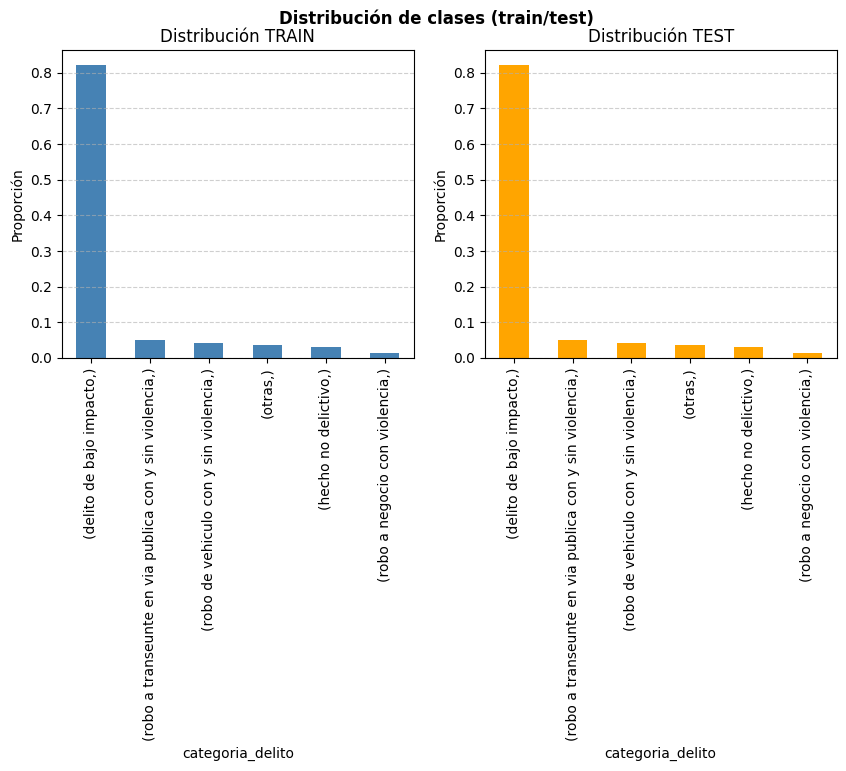

In [41]:
# Distribución actual de la clase
dist_train, dist_test, ratio = myUtils.analyze_class_distribution(y_train, y_test)

**¿Qué es lo que se suele hacer en casos de desbalanceo "extremo"?**
| Ratio | Nivel de desbalance | Acción recomendada                                             |
| ----- | ------------------- | -------------------------------------------------------------- |
| ≤ 2x  | Leve                | Entrenar normalmente (usar F1-macro)                           |
| 2–5x  | Moderado            | Usar `class_weight='balanced'` o `scale_pos_weight` en XGBoost |
| > 5x  | Fuerte              | Oversampling (SMOTE, RandomOverSampler) o undersampling        |


In [42]:
print(f"Ratio de desbalanceo: {ratio:.2f}")

Ratio de desbalanceo: 59.15


# **6. Balanceo**

Como tenemos un fuerte nivel de desbalance, es necesario balancear la clase. Pero no podemos hacerlo precipitadamente.

In [43]:
# Si y_train viene de un DataFrame con una sola columna
if isinstance(y_train, pd.DataFrame):
    y_train = y_train.squeeze()  # convierte (n,1) → (n,)

class_weight_dict, sample_weight_train = myUtils.make_class_weights(y_train)

print(" class_weight (train):")
for k, v in class_weight_dict.items():
    print(f"  {k}: {v:.2f}")
print(f"\n sample_weight (vector) listo: shape={sample_weight_train.shape}")

Clases detectadas: 6 → ['delito de bajo impacto', 'hecho no delictivo', 'otras', 'robo a negocio con violencia', 'robo a transeunte en via publica con y sin violencia', 'robo de vehiculo con y sin violencia']
 class_weight (train):
  delito de bajo impacto: 0.20
  hecho no delictivo: 5.27
  otras: 4.47
  robo a negocio con violencia: 11.98
  robo a transeunte en via publica con y sin violencia: 3.25
  robo de vehiculo con y sin violencia: 3.89

 sample_weight (vector) listo: shape=(159771,)


Observamos que, clases poco frecuentes reciben un peso mayor (para que el modelo las valore mejor durante el entrenamiento).

La función devuelve una tupla:

* **class_weight_dict**: se pasa a modelos que aceptan el parámetro class_weight
(e.g. DecisionTreeClassifier, RandomForestClassifier, LogisticRegression, SVC).

* **sample_weight**: se pasa al método .fit() de modelos que no aceptan class_weight
pero sí pesos de muestra (como XGBoost).

# **7. Entrenamiento**

In [44]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

In [45]:
# ------------------------------------------------------------
# Model zoo
# Nota: varios modelos NO aceptan input sparse denso (p.ej., GaussianNB, MLP).
# Si usamos X_full (tabular+TFIDF → CSR), nos conviene activar los que soportan CSR.
# ------------------------------------------------------------
def myTraditionalModels_old():
    models = []
    # compatibles con CSR
    models.append(("KNN (k=25, distance)",
                   KNeighborsClassifier(n_neighbors=25, weights="distance", n_jobs=-1)))
    models.append(("LogReg (C=1, balanced)",
                   LogisticRegression(multi_class="multinomial", solver="lbfgs",
                                      C=1.0, class_weight="balanced",
                                      max_iter=2000, n_jobs=-1)))
    models.append(("DecisionTree (depth=None)",
                   DecisionTreeClassifier(max_depth=None, min_samples_leaf=1, random_state=SEED)))
    models.append(("RandomForest (n=400)",
                   RandomForestClassifier(n_estimators=400, max_depth=None,
                                         class_weight="balanced_subsample", n_jobs=-1, random_state=SEED)))
    #  GaussianNB requiere denso: solo actívalo si usas TABULAR sin TF-IDF y lo pasas a .values
    # models.append(("GaussianNB", GaussianNB(var_smoothing=1e-9)))
    return models

In [46]:
def myTraditionalModels():
    """
    Devuelve dos listas:
      - scaled   : modelos que prefieren X_train_full_scaled (sensibles a escala)
      - unscaled : modelos que prefieren X_train_full_unscaled (árboles/boosting)
    Experimento con parámetros modestos para no exceder tiempo. Todos aceptan CSR.
    """
    # -----------------------------
    # Modelos para X_scaled
    # -----------------------------
    scaled = [
        # KNN: barato si k moderado; coste ~ O(n * k) por pred
        ("KNN (k=5, distance)",
         KNeighborsClassifier(n_neighbors=5, weights="distance", n_jobs=-1)),

        # LogReg multinomial: suele ir muy bien con TF-IDF; coste medio (itera hasta converger)
        ("LogReg (C=1, balanced)",
         LogisticRegression(multi_class="multinomial", solver="lbfgs",
                            C=1.0, class_weight="balanced", max_iter=1500, n_jobs=-1, random_state=SEED)),

        # Variante más regularizada (rápida/estable en alta dimensión)
        ("RidgeClassifier (alpha=1.0)",
         RidgeClassifier(alpha=1.0, random_state=SEED)),

        # LinearSVC: rápido en alto d; no da proba pero sí decision_function
        ("LinearSVC (C=0.4, balanced)",
         LinearSVC(C=0.4, class_weight="balanced", dual="auto", tol=1e-3, max_iter=1500, random_state=SEED)),

        ("SVC RBF (fast-ish)",
             SVC(kernel="rbf",
             C=0.2,      # más regularización, entonces menos SV pero más rápido
             gamma="scale",
             class_weight="balanced",
             tol=5e-2,              # tolerancia más laxa acelera
             max_iter=5000,         # tope de iteraciones (evita eternizarse) ... pero necesita mucho para funcionar
             cache_size=1000,       # MB para kernel cache (si tienes RAM)
             probability=False,
             random_state=SEED))    
    ]

    # -----------------------------
    # Modelos para X_unscaled (árboles)
    # -----------------------------
    unscaled = [
        # Árbol simple: muy rápido; buena línea base interpretable
        ("DecisionTree (depth=None, min_leaf=1)",
         DecisionTreeClassifier(max_depth=None, min_samples_leaf=1, random_state=SEED)),

        # RandomForest moderado: robusto; n_estimators moderado para tiempo razonable
        ("RandomForest (n=500, balanced_subsample)",
         RandomForestClassifier(n_estimators=500, max_depth=None, min_samples_leaf=1,
                               class_weight="balanced_subsample", n_jobs=-1, random_state=SEED)),

        # ExtraTrees: similar a RF pero aún más rápido; útil como baseline fuerte
        ("ExtraTrees (n=500, depth=None)",
         ExtraTreesClassifier(n_estimators=500, max_depth=None, n_jobs=-1, random_state=SEED)),

        # XGBoost: potente; params modestos (árboles poco profundos, lr moderado)
        ("XGBoost (hist, n=500, depth=6, eta=0.08)",
         XGBClassifier(
            objective="multi:softprob",
            num_class=n_classes,   # opcional si pasas y codificado
            n_estimators=500,
            max_depth=6,
            learning_rate=0.08,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method="hist",
            reg_lambda=1.0,
            eval_metric="mlogloss",  # evita warnings de métrica
            n_jobs=-1,
            random_state=SEED
            )),
    ]

    # -----------------------------
    # Modelos basados en Multilayer Perceptron (Red neuronal multicapas)
    # Excepcionalmente, aqui usamos RandomOverSampler para duplicar 
    # muestras de clases minoritarias dentro de cada fold, evitando data leakage
    # -----------------------------
    mlp_models = [
    ("ROS+MLP (64, early_stop)",
     Pipeline(steps=[
         ("ros", RandomOverSampler(random_state=SEED)),   # rebalancea en cada fit del CV
         ("mlp", MLPClassifier(
             hidden_layer_sizes=(64,),
             activation="relu", solver="adam",
             alpha=1e-4, learning_rate_init=1e-3,
             batch_size=512, max_iter=1500,
             early_stopping=True, n_iter_no_change=8,
             random_state=SEED))
     ])),
    ("ROS+MLP (128x64, early_stop)",
     Pipeline(steps=[
         ("ros", RandomOverSampler(random_state=SEED)),
         ("mlp", MLPClassifier(
             hidden_layer_sizes=(128,64),
             activation="relu", solver="adam",
             alpha=2e-4, learning_rate_init=8e-4,
             batch_size=512, max_iter=1500,
             early_stopping=True, n_iter_no_change=8,
             random_state=SEED))
     ])),
]

    return {"scaled": scaled, "unscaled": unscaled, "MLP-models": mlp_models}


Notas de tiempo (aprox.):

- Más rápidos: DecisionTree, Ridge, LinearSVC, ExtraTrees.

- Medios: LogReg, RandomForest.

- Más costosos: SVC RBF (alto d), XGBoost (n_estimators).


Además consierar en modelos como SVC que:

- probability=False: más rápido porque usa márgenes/aproximaciones (decision_function) que permanecen útiles para ROC/F1.
- probability=True: más lento, pero devuelve probabilidades reales (predict_proba).

In [47]:
# Ejecutar OOF CV para ambos grupos y unir resultados
zoo = myTraditionalModels()

# --- Grupo SCALED ---
oof_scaled, df_scaled = myUtils.collect_oof_predictions(
    models=zoo["scaled"],
    X=X_train_full_scaled,
    y=y_train,
    cv=cv5,
    fit_params=None,     # no usamos sample_weight aquí
    verbose=True
)

df_scaled["features"] = "Full Scaled"
print("Modelos entrenados con features escaladas")

OOF → KNN (k=5, distance)
OOF → LogReg (C=1, balanced)
OOF → RidgeClassifier (alpha=1.0)
OOF → LinearSVC (C=0.4, balanced)
OOF → SVC RBF (fast-ish)


/Users/jorgevalverde/Documents/myEnv/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/jorgevalverde/Documents/myEnv/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/jorgevalverde/Documents/myEnv/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/jorgevalverde/Documents/myEnv/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/j

Modelos entrenados con features escaladas


In [48]:
# --- Grupo UNSCALED (pasando sample_weight en CV) ---
fit_params = {"sample_weight": sample_weight_train}  # para RF/XGB/Tree
oof_unscaled_enc, df_unscaled = myUtils.collect_oof_predictions(
    models=zoo["unscaled"],
    X=X_train_full_unscaled,
    y=y_train_enc,
    cv=cv5,
    fit_params=fit_params,
    verbose=True
)

df_unscaled["features"] = "Full Unscaled"
print("Modelos entrenados con features NO escaladas")

OOF → DecisionTree (depth=None, min_leaf=1)
OOF → RandomForest (n=500, balanced_subsample)
OOF → ExtraTrees (n=500, depth=None)
OOF → XGBoost (hist, n=500, depth=6, eta=0.08)
Modelos entrenados con features NO escaladas


In [49]:
# decodificar los labels de la clase
oof_unscaled = myUtils._decode_oof_labels(oof_unscaled_enc, le)

In [50]:
# MLPClassifier no acepta matrices scipy.sparse. Entonces debemos convertir el bloque 
# TF-IDF con TruncatedSVD (LSA):
#  - Reducir TF-IDF CSR a k componentes densos (p.ej., 300–600).
#  - Concatenar con tus features tabulares densas (DataFrame .values).
#  - Escalar el conjunto denso (StandardScaler).

### fit_params_mlp = {"sample_weight": sample_weight_train} # No será necesário
oof_mlp, df_mlp = myUtils.collect_oof_predictions(
    models=zoo["MLP-models"],
    X=X_train_mlp,
    y=y_train,                 # MLP acepta labels string sin problema
    cv=cv5,
    fit_params=None, # <- no pasar sample_weight
    verbose=True
)
df_mlp["features"] = "Dense (SVD+Tab+Scaled)"
print("Modelos entrenados con features densas (SVD+Tab+Scaled)")

OOF → ROS+MLP (64, early_stop)
OOF → ROS+MLP (128x64, early_stop)
Modelos entrenados con features densas (SVD+Tab+Scaled)


In [51]:
# Leaderboard unificado
leaderboard = (
    pd.concat([df_scaled, df_unscaled, df_mlp], axis=0, ignore_index=True)
      .sort_values(["macro_f1_oof", "bal_acc_oof"], ascending=False)
      .reset_index(drop=True)
)

# Ver todo, aqui ya aparece rankeado
leaderboard

,model,macro_f1_oof,bal_acc_oof,acc_oof,roc_auc_macro_oof,features
0,"XGBoost (hist, n=500, depth=6, eta=0.08)",0.903506,0.966450,0.971215,0.997153,Full Unscaled
1,"ROS+MLP (128x64, early_stop)",0.893070,0.921679,0.973669,0.995239,Dense (SVD+Tab+Scaled)
2,"DecisionTree (depth=None, min_leaf=1)",0.892083,0.889269,0.980159,0.938373,Full Unscaled
3,"ExtraTrees (n=500, depth=None)",0.891115,0.872137,0.984046,0.996658,Full Unscaled
4,"LinearSVC (C=0.4, balanced)",0.890691,0.979910,0.958397,0.996690,Full Scaled
5,"ROS+MLP (64, early_stop)",0.885104,0.963110,0.960813,0.996029,Dense (SVD+Tab+Scaled)
6,"RandomForest (n=500, balanced_subsample)",0.883865,0.862046,0.984115,0.996881,Full Unscaled
7,"LogReg (C=1, balanced)",0.858044,0.985430,0.938268,0.996593,Full Scaled
8,RidgeClassifier (alpha=1.0),0.828192,0.822868,0.983138,0.996408,Full Scaled
9,"KNN (k=5, distance)",0.591408,0.501985,0.892171,0.842109,Full Scaled


In [52]:
# Guardar leaderboard a CSV
RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

prefix = "zoo_experimental"  # <- define tu prefijo
leaderboard_path = os.path.join(RESULTS_DIR, f"{prefix}_leaderboard.csv")

leaderboard.to_csv(leaderboard_path, index=False, encoding="utf-8-sig")
print(f" Leaderboard guardado en: {leaderboard_path}")

 Leaderboard guardado en: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/zoo_experimental_leaderboard.csv


/Users/jorgevalverde/Documents/myEnv/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/jorgevalverde/Documents/myEnv/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/jorgevalverde/Documents/myEnv/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/jorgevalverde/Documents/myEnv/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/j

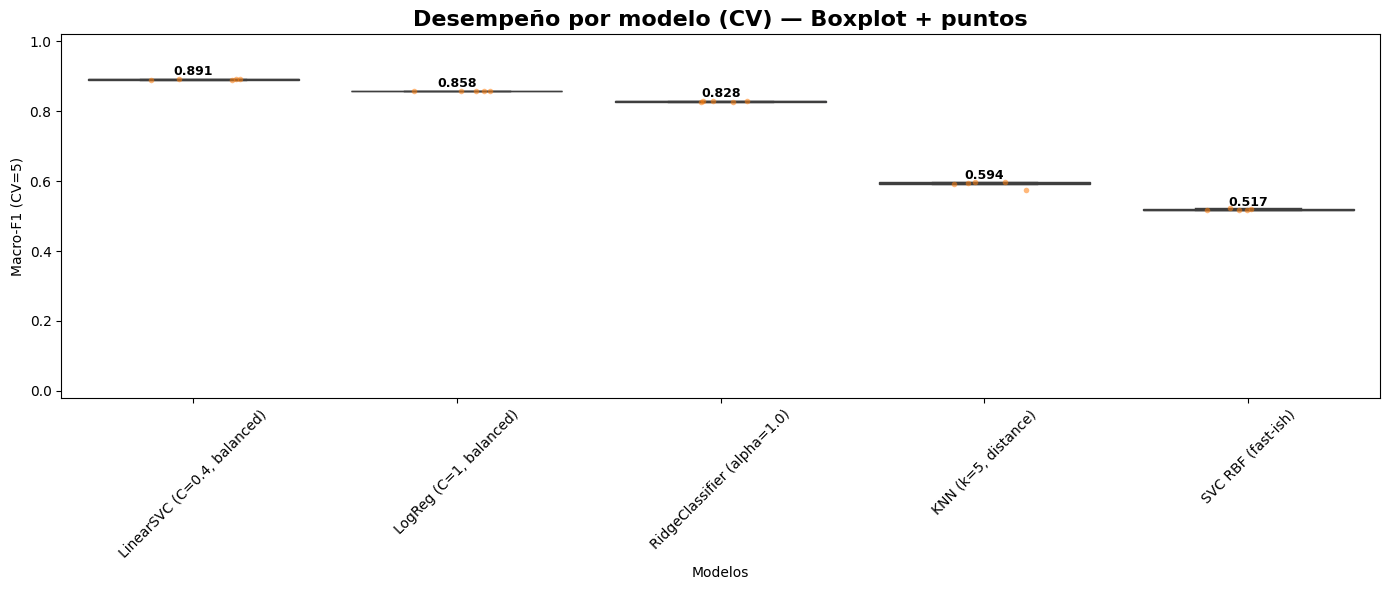


 Top-10 por mediana de Macro-F1:


,median,mean,std,iqr
model,,,,
"LinearSVC (C=0.4, balanced)",0.891,0.891,0.001,0.002
"LogReg (C=1, balanced)",0.858,0.858,0.001,0.001
RidgeClassifier (alpha=1.0),0.828,0.828,0.002,0.003
"KNN (k=5, distance)",0.594,0.591,0.009,0.006
SVC RBF (fast-ish),0.517,0.519,0.002,0.003



 Top-10 más estables (menor std):


,median,mean,std,iqr
model,,,,
"LogReg (C=1, balanced)",0.858,0.858,0.001,0.001
"LinearSVC (C=0.4, balanced)",0.891,0.891,0.001,0.002
RidgeClassifier (alpha=1.0),0.828,0.828,0.002,0.003
SVC RBF (fast-ish),0.517,0.519,0.002,0.003
"KNN (k=5, distance)",0.594,0.591,0.009,0.006


In [53]:
# Boxplot Macro-F1 en CV para modelos con features ESCALADAS ---
_ = myUtils.boxplot_macro_f1_cv(
    models=zoo["scaled"],
    X=X_train_full_scaled,
    y=y_train,
    cv=cv5
)

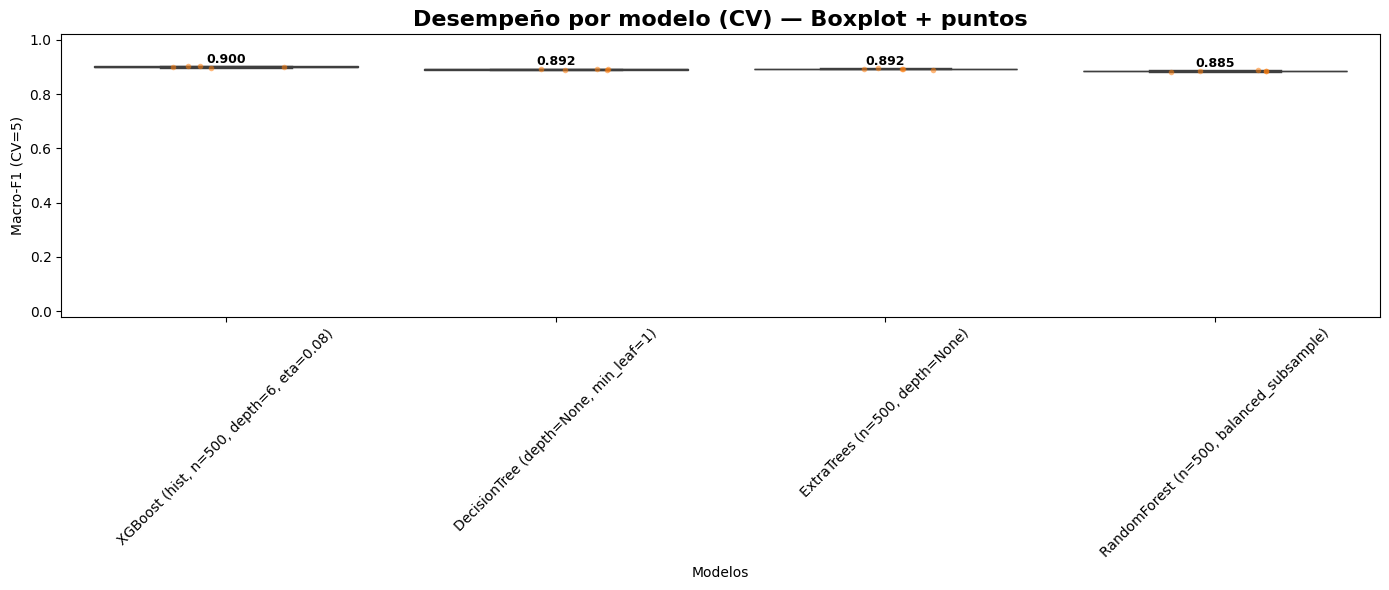


 Top-10 por mediana de Macro-F1:


,median,mean,std,iqr
model,,,,
"XGBoost (hist, n=500, depth=6, eta=0.08)",0.900,0.900,0.003,0.005
"DecisionTree (depth=None, min_leaf=1)",0.892,0.892,0.002,0.002
"ExtraTrees (n=500, depth=None)",0.892,0.892,0.002,0.001
"RandomForest (n=500, balanced_subsample)",0.885,0.885,0.002,0.002



 Top-10 más estables (menor std):


,median,mean,std,iqr
model,,,,
"DecisionTree (depth=None, min_leaf=1)",0.892,0.892,0.002,0.002
"RandomForest (n=500, balanced_subsample)",0.885,0.885,0.002,0.002
"ExtraTrees (n=500, depth=None)",0.892,0.892,0.002,0.001
"XGBoost (hist, n=500, depth=6, eta=0.08)",0.900,0.900,0.003,0.005


In [54]:
# Boxplot Macro-F1 en CV para modelos con features NO ESCALADAS ---
_ = myUtils.boxplot_macro_f1_cv(
    models=zoo["unscaled"],
    X=X_train_full_unscaled,
    y=y_train_enc,
    cv=cv5
)

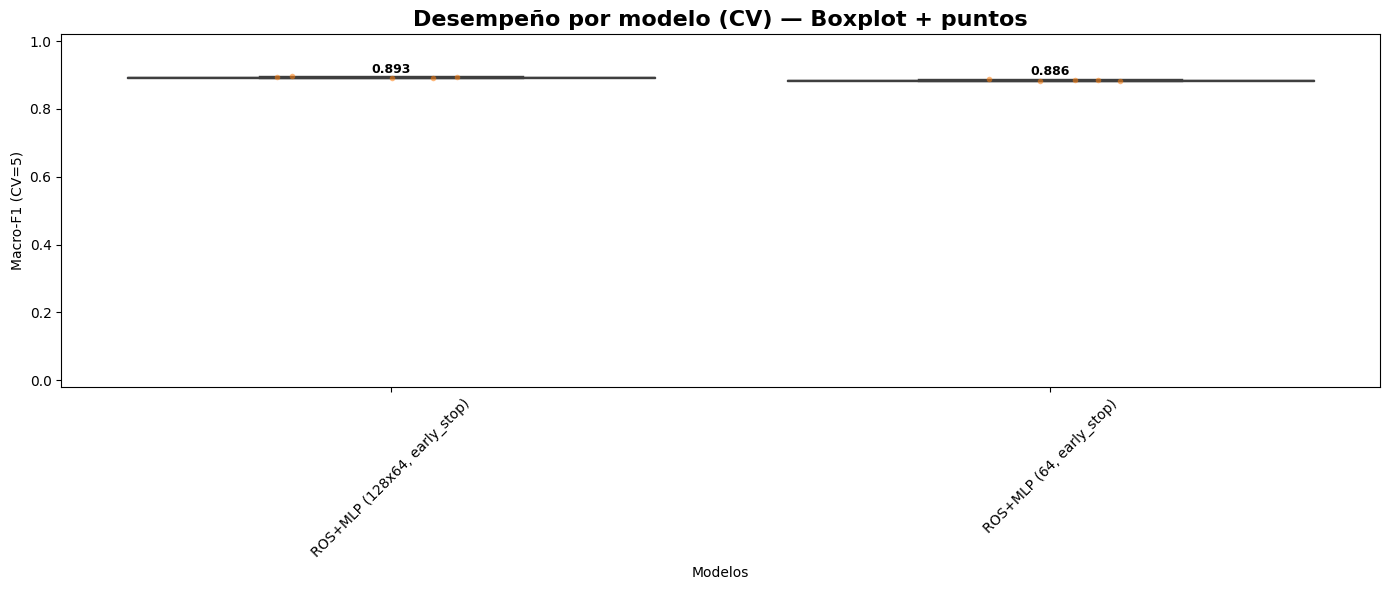


 Top-10 por mediana de Macro-F1:


,median,mean,std,iqr
model,,,,
"ROS+MLP (128x64, early_stop)",0.893,0.893,0.002,0.002
"ROS+MLP (64, early_stop)",0.886,0.885,0.002,0.003



 Top-10 más estables (menor std):


,median,mean,std,iqr
model,,,,
"ROS+MLP (128x64, early_stop)",0.893,0.893,0.002,0.002
"ROS+MLP (64, early_stop)",0.886,0.885,0.002,0.003


In [55]:
# Boxplot Macro-F1 en CV para modelos con features para MLP ---
_ = myUtils.boxplot_macro_f1_cv(
    models=zoo["MLP-models"],
    X=X_train_mlp,
    y=y_train,
    cv=cv5
)

Matrices de Confusión — ESCALADAS


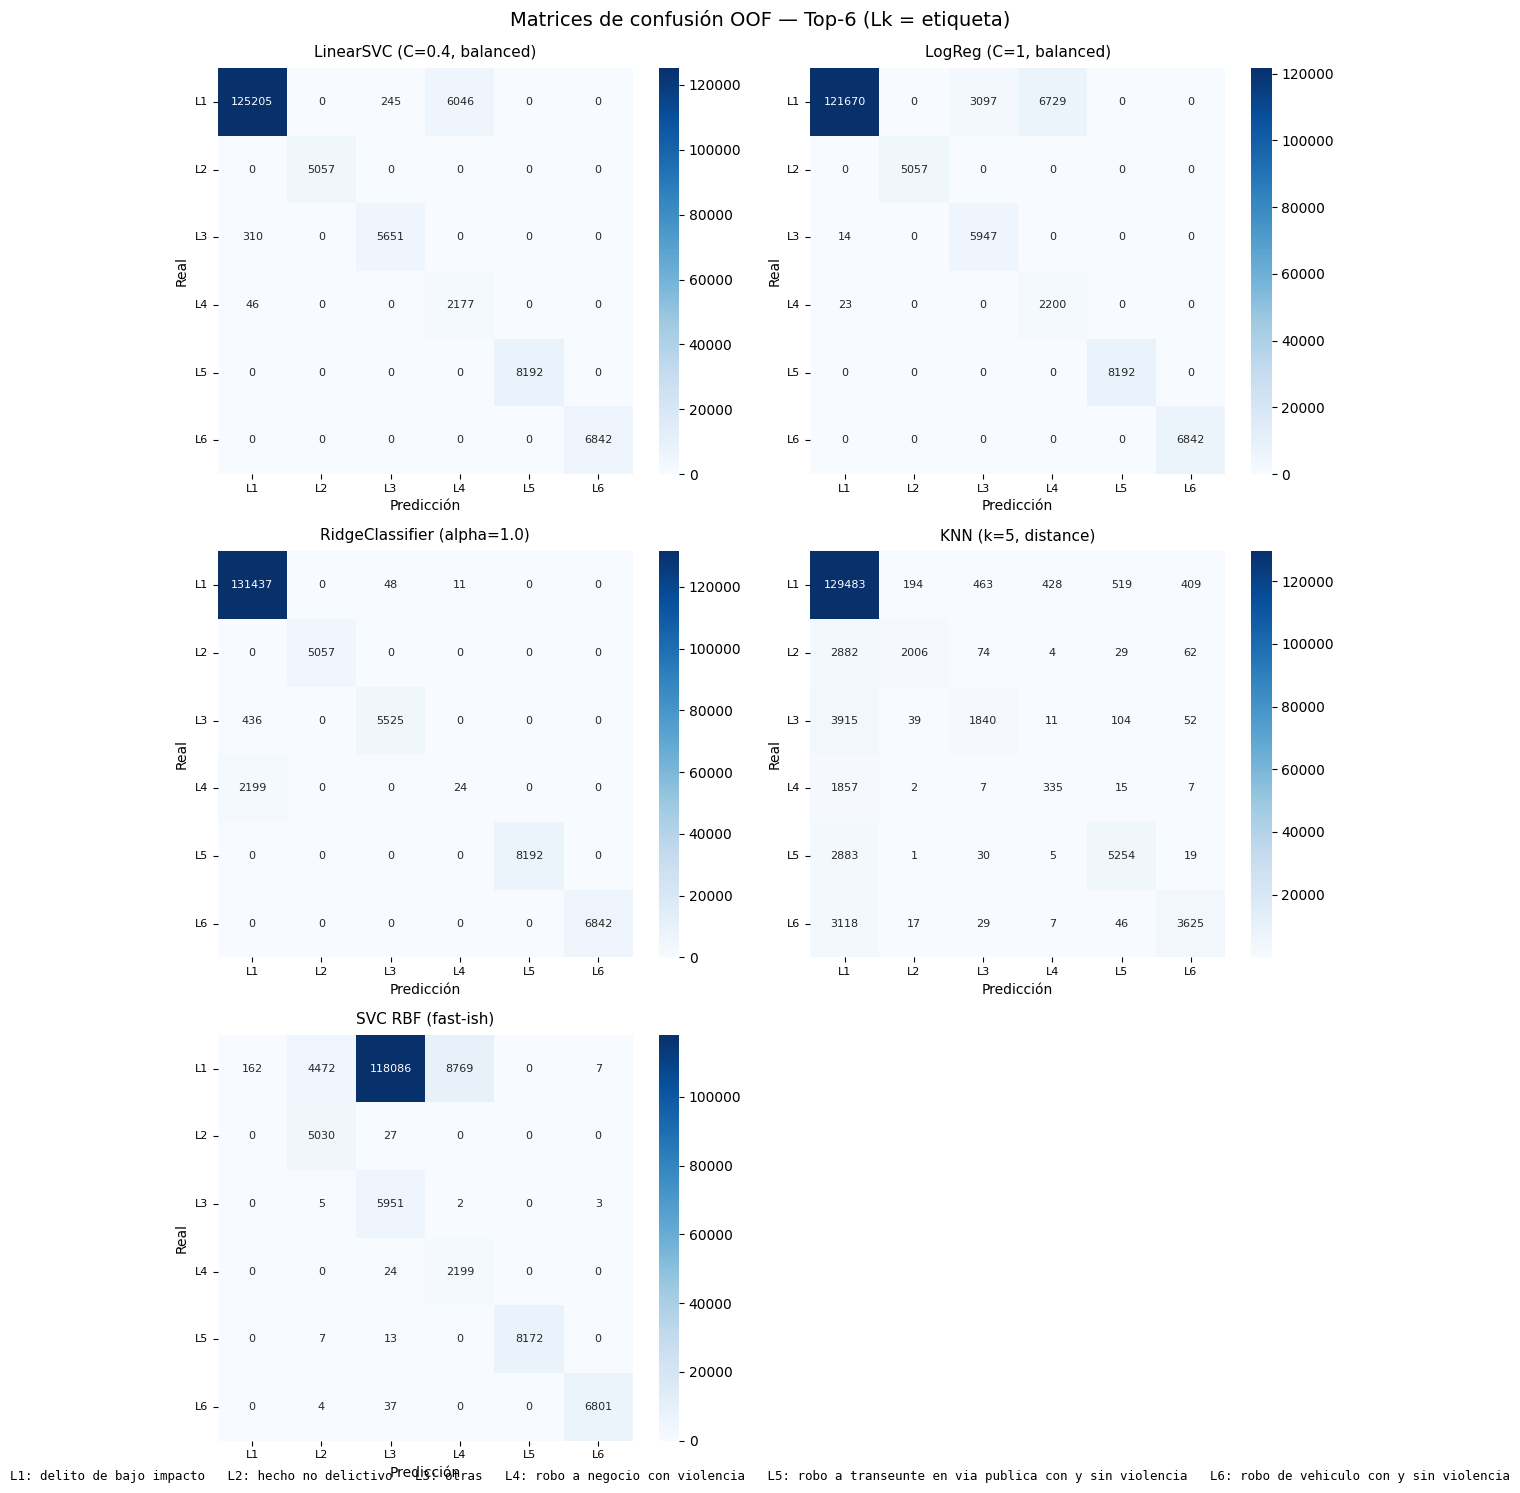

In [56]:
TOP_N_MODELS = 6

# Matriz de Confusión para modelos con features ESCALADAS
print("Matrices de Confusión — ESCALADAS")
myUtils.plot_confusions_topN(
    oof_dict=oof_scaled,
    df_oof=df_scaled,
    N=TOP_N_MODELS,
    normalize=False  # True aplica recall por clase
)

Matrices de Confusión — NO ESCALADAS


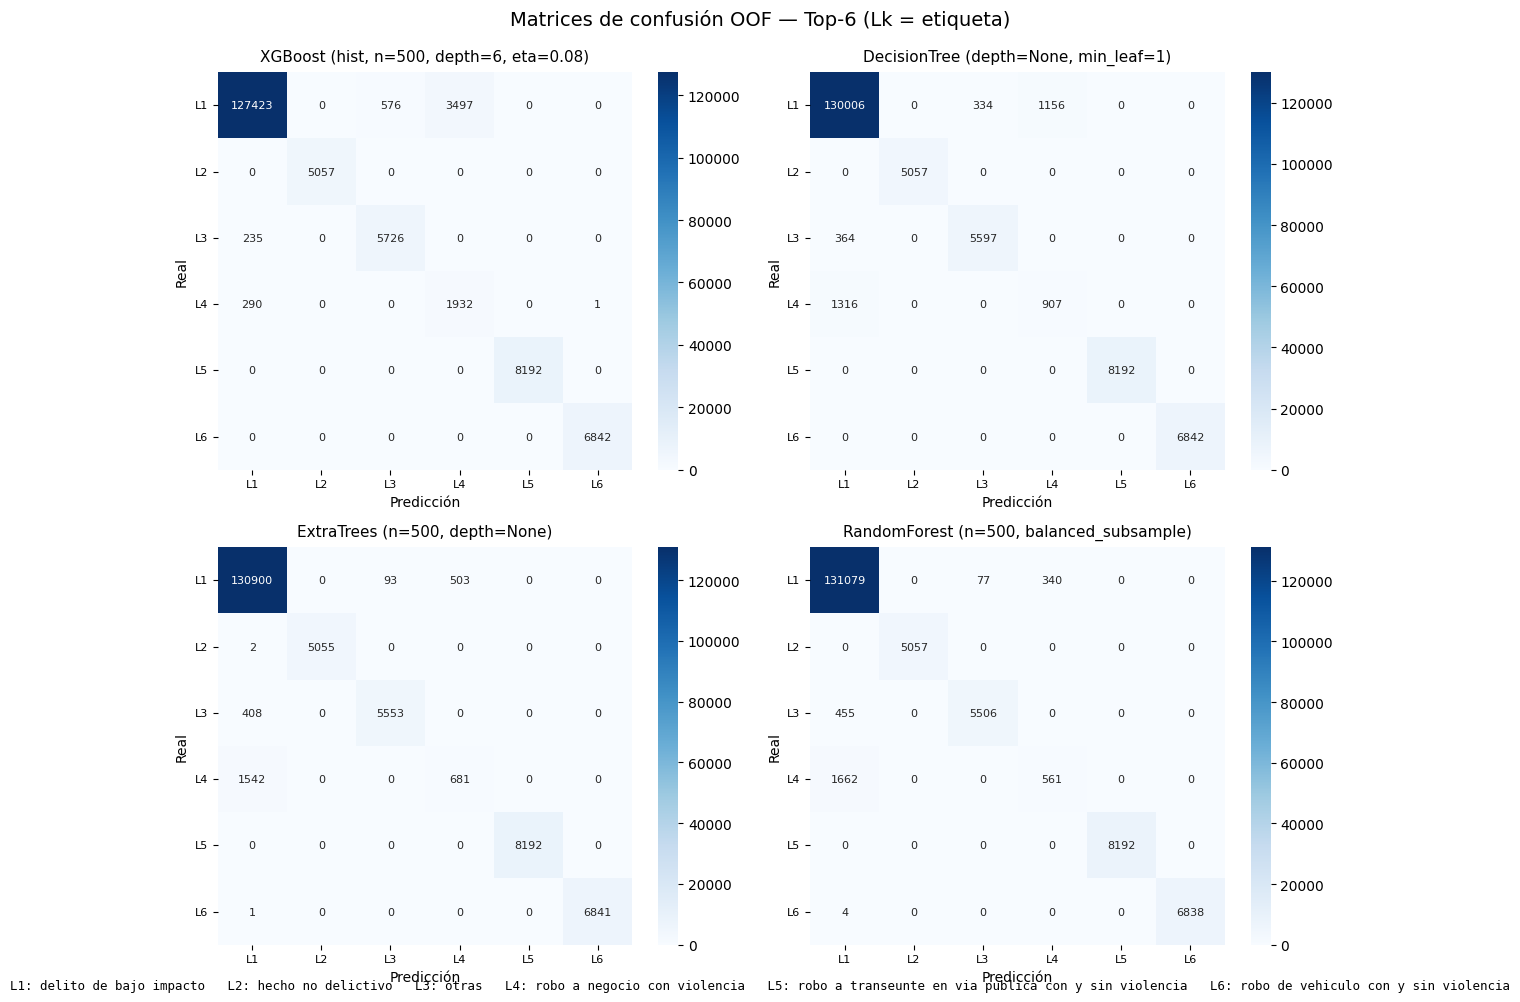

In [57]:
# Confusiones para modelos con features NO ESCALADAS
print("Matrices de Confusión — NO ESCALADAS")
myUtils.plot_confusions_topN(
    oof_dict=oof_unscaled,
    df_oof=df_unscaled,
    N=TOP_N_MODELS,
    normalize=False
)

Matrices de Confusión — DENSAS


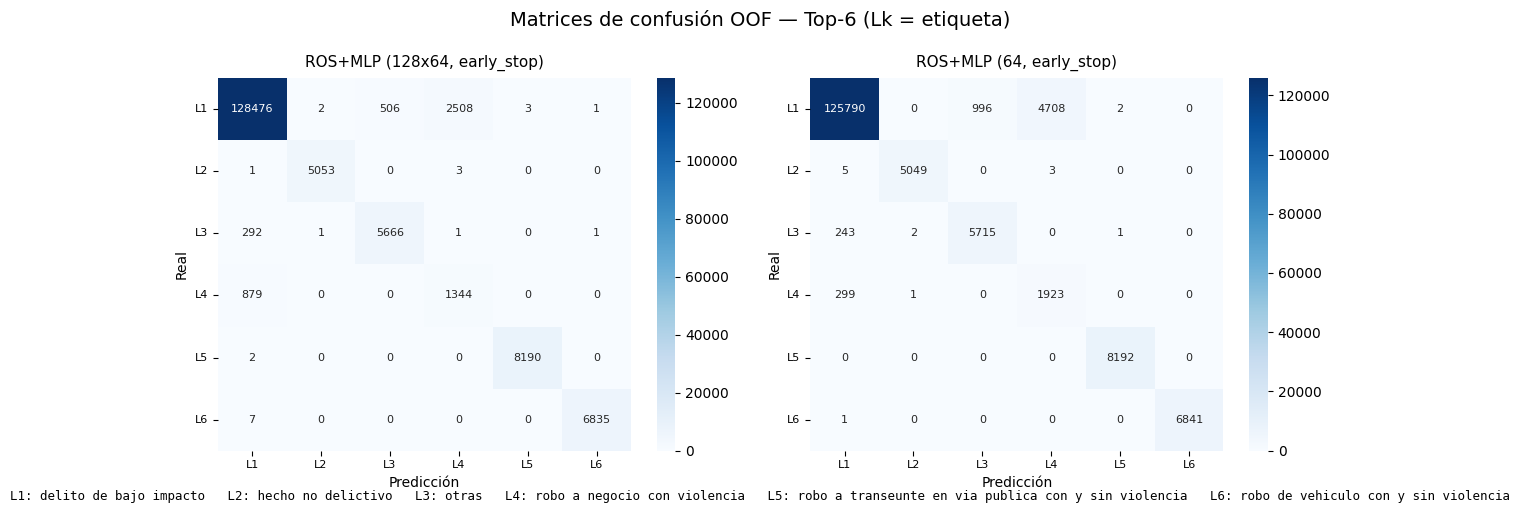

In [58]:
# Confusiones para modelos con features DENSAS
print("Matrices de Confusión — DENSAS")
myUtils.plot_confusions_topN(
    oof_dict=oof_mlp,
    df_oof=df_mlp,
    N=TOP_N_MODELS,
    normalize=False
)

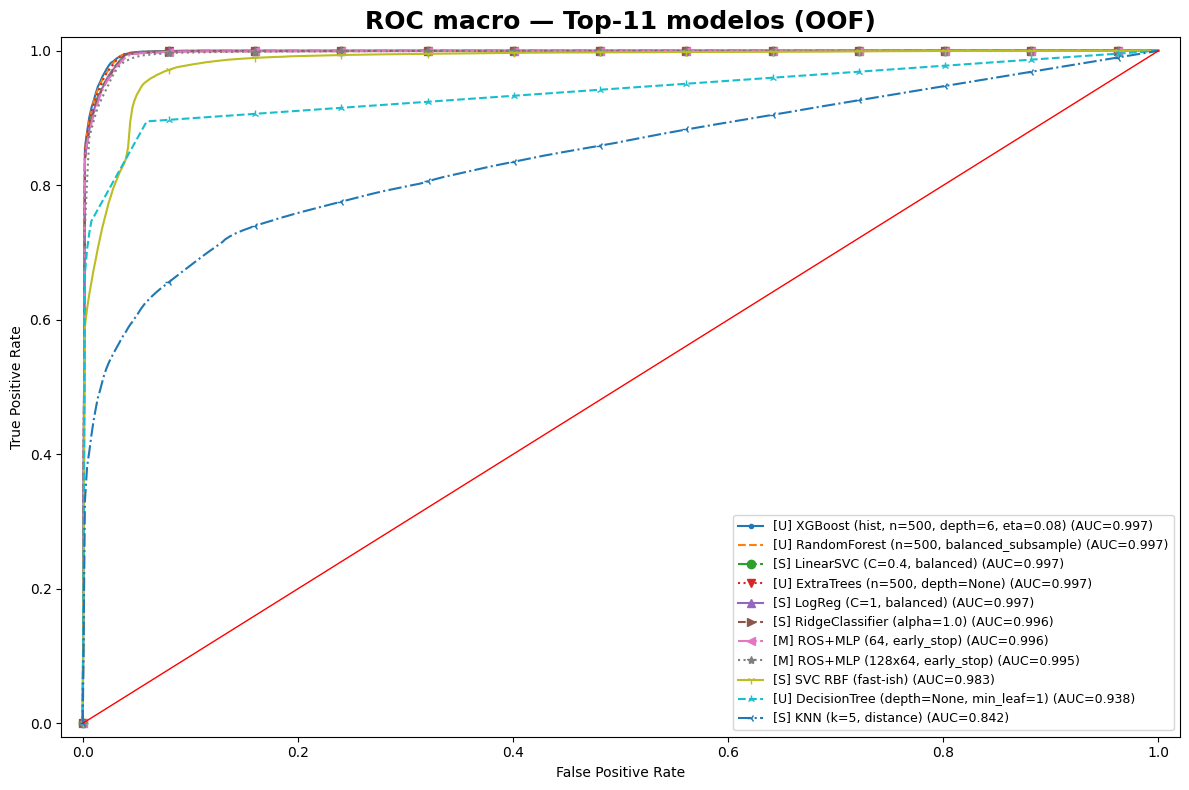

In [59]:
# 1) Etiquetar modelos para distinguir grupos
df_s = df_scaled.copy()
df_s["model"] = "[S] " + df_s["model"]      # S = Scaled
df_u = df_unscaled.copy()
df_u["model"] = "[U] " + df_u["model"]      # U = Unscaled
df_m = df_mlp.copy()
df_m["model"] = "[M] " + df_m["model"]      # MLP (Dense)

# 2) Combinar df_oof y oof_dict con los nombres actualizados
df_all = pd.concat([df_s, df_u, df_m], ignore_index=True)

oof_s = {("[S] " + k): v for k, v in oof_scaled.items()}
oof_u = {("[U] " + k): v for k, v in oof_unscaled.items()}
oof_m_tagged = {("[M] " + k): v for k, v in oof_mlp.items()}
oof_all = {**oof_s, **oof_u, **oof_m_tagged}

# 3) Curvas ROC macro en una sola figura
TOP_N_MODELS = len(df_all) # aqui visualizaremos todos, si se quiere el verdadero minimo, usar: min(10, len(df_all))
myUtils.plot_macro_roc_topN(oof_all, df_all, N=TOP_N_MODELS)


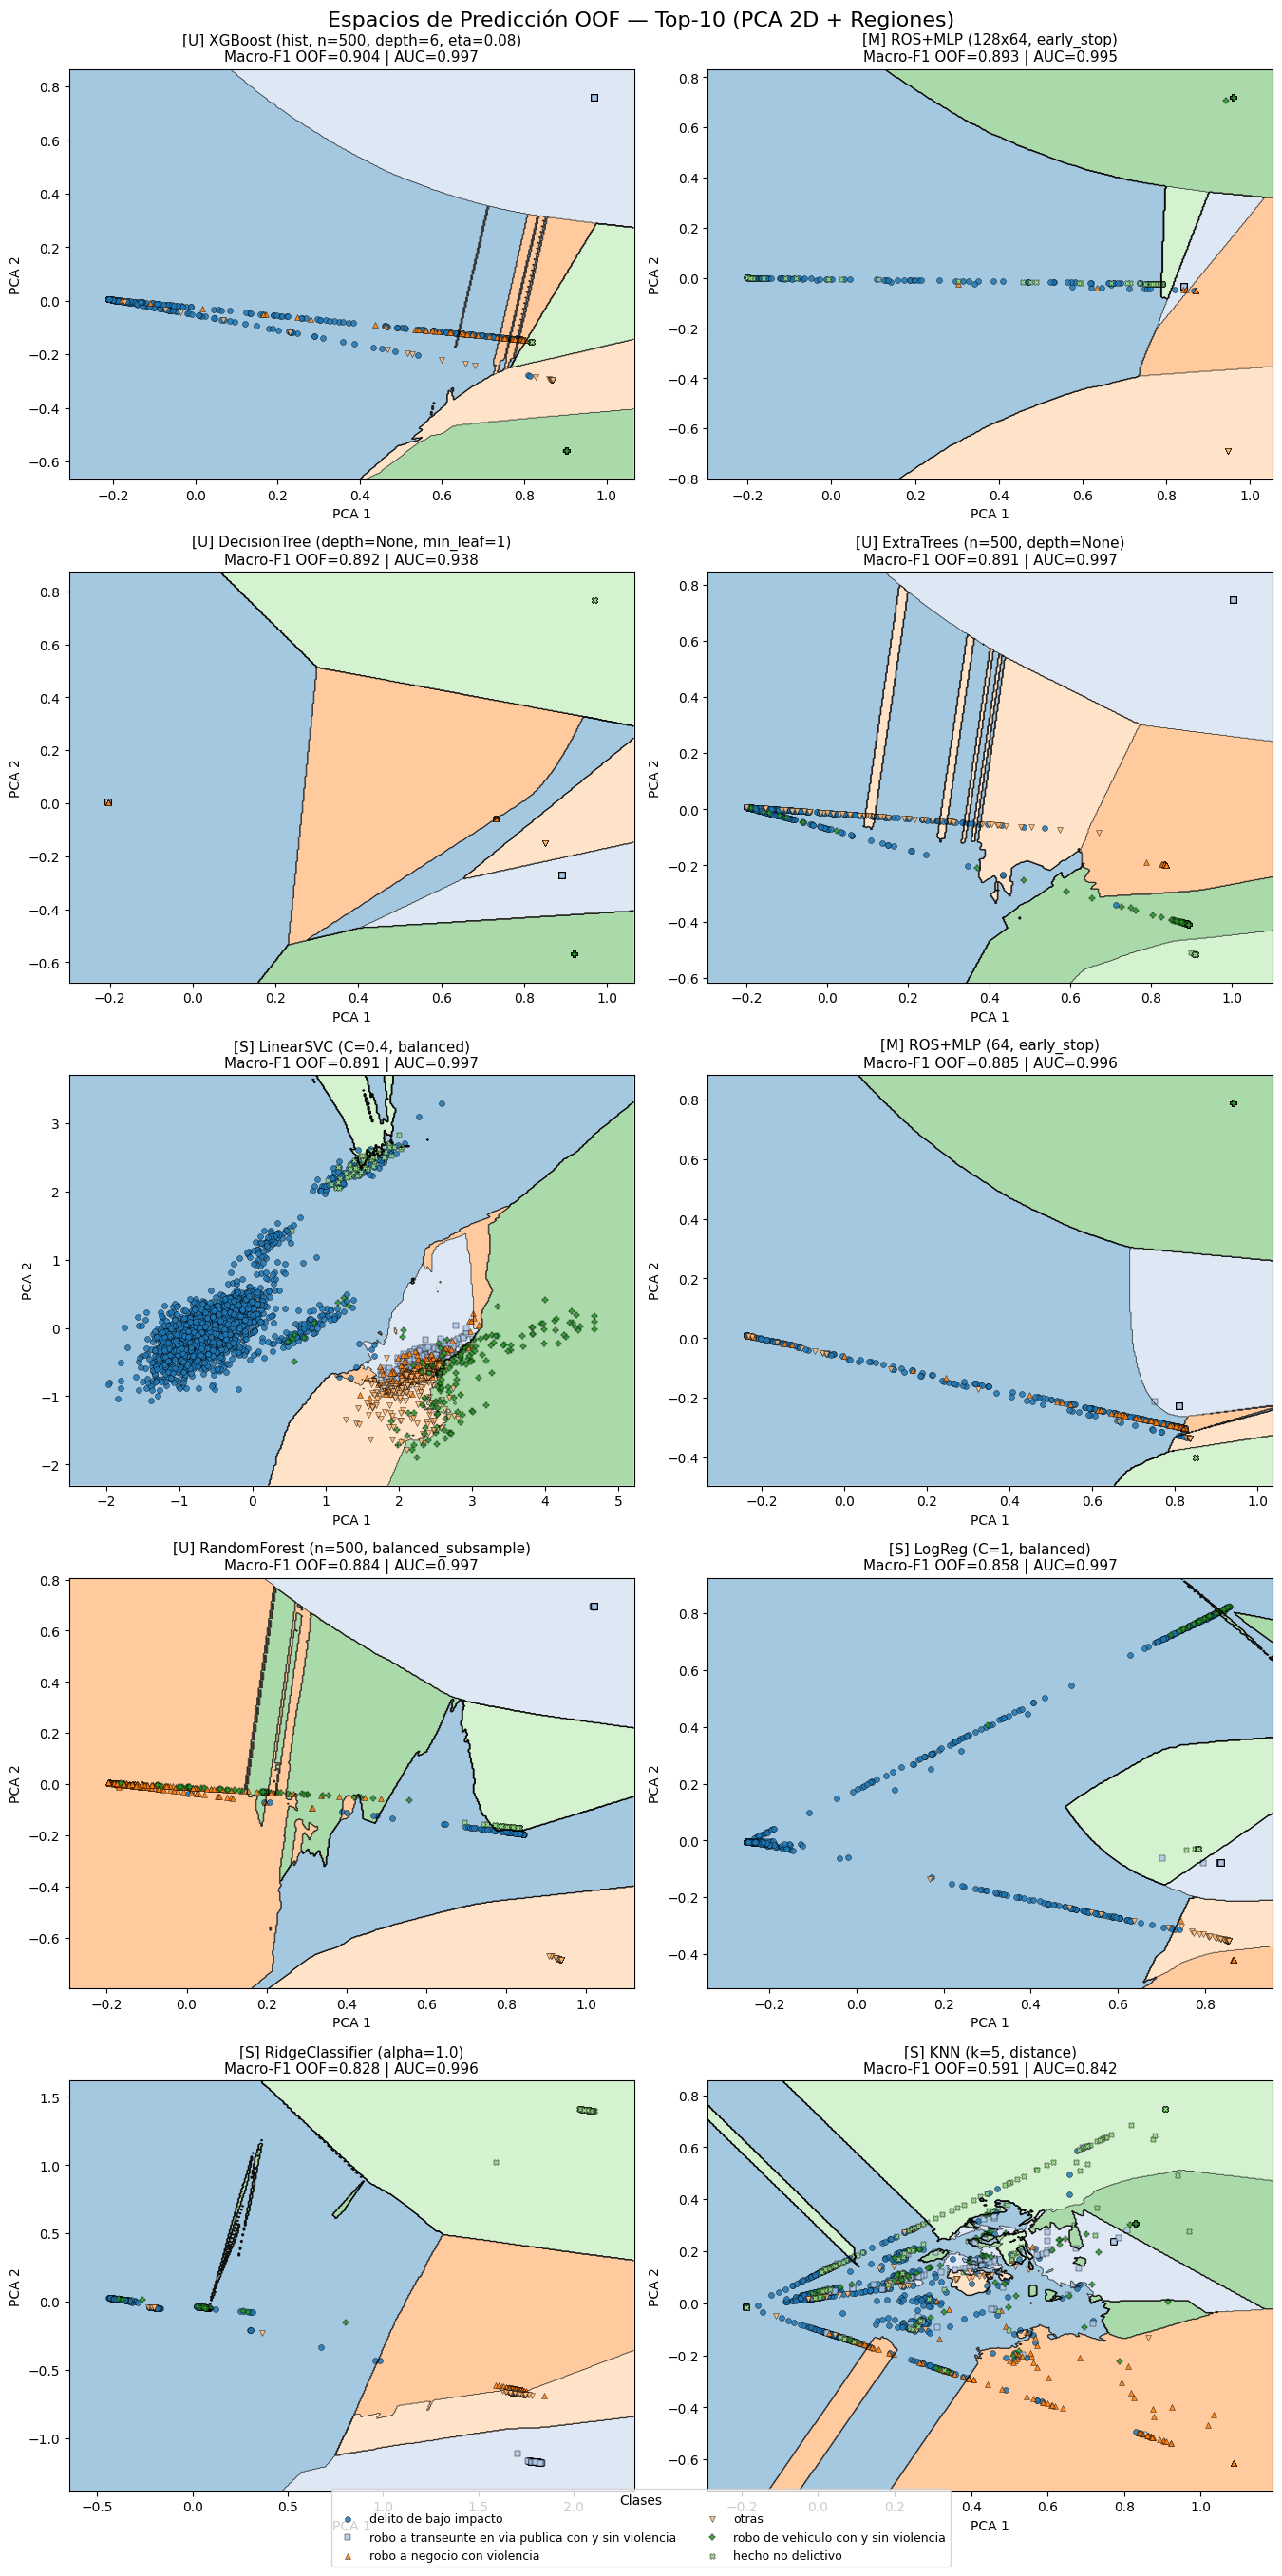

In [60]:
# Visualizar espacio de predicción en PCA 2D (scores OOF)
myUtils.plot_prediction_space_topN(
    oof_dict=oof_all,
    df_oof=df_all,
    N=10,  # nro de modelos a mostrar
    sample_size=4000,
    knn_k=15,
    grid_step=450,          # sube para mallas más suaves
    region_alpha=0.40,
    boundary_alpha=0.75,
    random_state=SEED
)

# **8. TEST**

In [61]:
# Ordenar el leaderboard combinado por Macro-F1 (y luego Balanced Acc)
df_top5 = (
    df_all.sort_values(["macro_f1_oof", "bal_acc_oof"], ascending=False)
          .head(5)
          .reset_index(drop=True)
)

print(" Top-5 modelos ENTRENADOS en el torneo:")
display(df_top5[["model", "macro_f1_oof", "bal_acc_oof", "roc_auc_macro_oof"]])


 Top-5 modelos ENTRENADOS en el torneo:


,model,macro_f1_oof,bal_acc_oof,roc_auc_macro_oof
0,"[U] XGBoost (hist, n=500, depth=6, eta=0.08)",0.903506,0.966450,0.997153
1,"[M] ROS+MLP (128x64, early_stop)",0.893070,0.921679,0.995239
2,"[U] DecisionTree (depth=None, min_leaf=1)",0.892083,0.889269,0.938373
3,"[U] ExtraTrees (n=500, depth=None)",0.891115,0.872137,0.996658
4,"[S] LinearSVC (C=0.4, balanced)",0.890691,0.979910,0.996690


In [62]:
# Reentrenar solo los modelos del Top-5
best_models = []
for name in df_top5["model"]:
    # identificar grupo por prefijo
    prefix = name[:3]
    clean_name = name[4:]  # quitar "[S]" "[U]" "[M]"
    if prefix == "[S]":
        group = "scaled"
        X_train_sel = X_train_full_scaled
        y_train_sel = y_train
        fit_params = None
    elif prefix == "[U]":
        group = "unscaled"
        X_train_sel = X_train_full_unscaled
        y_train_sel = y_train_enc if "XGB" in name else y_train
        fit_params = {"sample_weight": sample_weight_train}
    elif prefix == "[M]":
        group = "MLP-models"
        X_train_sel = X_train_mlp
        y_train_sel = y_train
        fit_params = None
    else:
        continue  # seguridad

    # encontrar el estimador original del zoológico
    est_base = next((m for m_name, m in zoo[group] if m_name == clean_name), None)
    if est_base is None:
        print(f" No encontrado: {name}")
        continue

    est = clone(est_base)
    print(f"Entrenando {name} ...")
    if fit_params:
        est.fit(X_train_sel, y_train_sel, **fit_params)
    else:
        est.fit(X_train_sel, y_train_sel)

    best_models.append((name, est))


Entrenando [U] XGBoost (hist, n=500, depth=6, eta=0.08) ...
Entrenando [M] ROS+MLP (128x64, early_stop) ...
Entrenando [U] DecisionTree (depth=None, min_leaf=1) ...
Entrenando [U] ExtraTrees (n=500, depth=None) ...
Entrenando [S] LinearSVC (C=0.4, balanced) ...


In [63]:
results_test = []

for name, model in best_models:
    prefix = name[:3]
    if prefix == "[S]":
        X_test_sel = X_test_full_scaled
        y_test_sel = y_test
    elif prefix == "[U]":
        X_test_sel = X_test_full_unscaled
        y_test_sel = y_test_enc if "XGBoost" in name else y_test
    elif prefix == "[M]":
        X_test_sel = X_test_mlp
        y_test_sel = y_test
    else:
        continue

    # Asegurar 1D
    y_true_1d = np.asarray(y_test_sel).ravel()
    y_pred_1d = np.asarray(model.predict(X_test_sel)).ravel()

    macro_f1 = f1_score(y_true_1d, y_pred_1d, average="macro")
    bal_acc  = balanced_accuracy_score(y_true_1d, y_pred_1d)
    acc      = accuracy_score(y_true_1d, y_pred_1d)

    results_test.append({
        "model": name,
        "macro_f1_test": macro_f1,
        "bal_acc_test": bal_acc,
        "acc_test": acc
    })

df_test_results = (pd.DataFrame(results_test)
                     .sort_values("macro_f1_test", ascending=False)
                     .reset_index(drop=True))

print(f"RESULTADOS DE TEST")
display(df_test_results)

RESULTADOS DE TEST


,model,macro_f1_test,bal_acc_test,acc_test
0,"[U] XGBoost (hist, n=500, depth=6, eta=0.08)",0.902606,0.962039,0.971484
1,"[M] ROS+MLP (128x64, early_stop)",0.892043,0.922304,0.973012
2,"[S] LinearSVC (C=0.4, balanced)",0.889581,0.982220,0.956939
3,"[U] ExtraTrees (n=500, depth=None)",0.885666,0.863567,0.985329
4,"[U] DecisionTree (depth=None, min_leaf=1)",0.862266,0.856504,0.978119


In [64]:
# guardamos

MODELS_DIR = os.path.join(RESULTS_DIR, "final_models")
os.makedirs(MODELS_DIR, exist_ok=True)

for name, model in best_models:
    safe_name = name.replace(" ", "_").replace("(", "").replace(")", "").replace("[", "").replace("]", "")
    path = os.path.join(MODELS_DIR, f"{safe_name}.joblib")
    joblib.dump(model, path)
    print(f" Guardado: {path}")

 Guardado: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/final_models/U_XGBoost_hist,_n=500,_depth=6,_eta=0.08.joblib
 Guardado: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/final_models/M_ROS+MLP_128x64,_early_stop.joblib
 Guardado: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/final_models/U_DecisionTree_depth=None,_min_leaf=1.joblib
 Guardado: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/final_models/U_ExtraTrees_n=500,_depth=None.joblib
 Guardado: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/final_models/S_LinearSVC_C=0.4,_balanced.joblib


In [68]:
# Añadimos un “manifest” para saber cuántas features esperaba cada modelo
# Esto nos permite, en inferencia, rutar automáticamente 
# cada modelo hacia la matriz que tenga exactamente ese número de columnas

MODEL_MANIFEST = []
for name, model in best_models:   # lista [(name, estimator)]
    nfeat = getattr(model, "n_features_in_", None)
    MODEL_MANIFEST.append({
        "model_name": name,
        "n_features_in": int(nfeat) if nfeat is not None else None
    })

MANIFEST_PATH = os.path.join(RESULTS_DIR, "model_manifest.json")
with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(MODEL_MANIFEST, f, ensure_ascii=False, indent=2)

print(f" Manifiesto de modelos guardado en:\n  {MANIFEST_PATH}")

 Manifiesto de modelos guardado en:
  /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/results/model_manifest.json


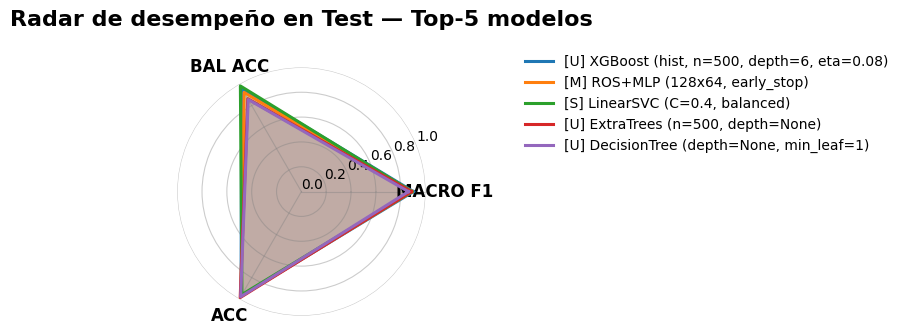

In [65]:
# Configuración general 
metrics = ["macro_f1_test", "bal_acc_test", "acc_test"]
labels = df_test_results["model"].tolist()
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist() + [0]

# Colores más definidos
palette = sns.color_palette("tab10", n_colors=len(df_test_results))

# Crear figura más amplia
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

# Graficar cada modelo
for idx, (_, row) in enumerate(df_test_results.iterrows()):
    values = [row[m] for m in metrics]
    values += values[:1]  # cerrar el círculo
    ax.plot(angles, values, linewidth=2.2, label=row["model"], color=palette[idx])
    ax.fill(angles, values, alpha=0.15, color=palette[idx])

# Personalización de ejes
ax.set_xticks(angles[:-1])
ax.set_xticklabels(
    [m.replace("_test", "").replace("_", " ").upper() for m in metrics],
    fontsize=12, fontweight="bold"
)
ax.set_yticks(np.linspace(0, 1, 6))
ax.set_yticklabels(["0.0", "0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=10)
ax.set_ylim(0, 1)


ax.set_title("Radar de desempeño en Test — Top-5 modelos", fontsize=16, weight="bold", pad=30)
ax.grid(True, color="gray", alpha=0.4)
ax.spines["polar"].set_visible(False)

# Leyenda externa 
ax.legend(
    bbox_to_anchor=(1.35, 1.1),
    loc="upper left",
    fontsize=10,
    frameon=False
)

plt.tight_layout()
plt.show()


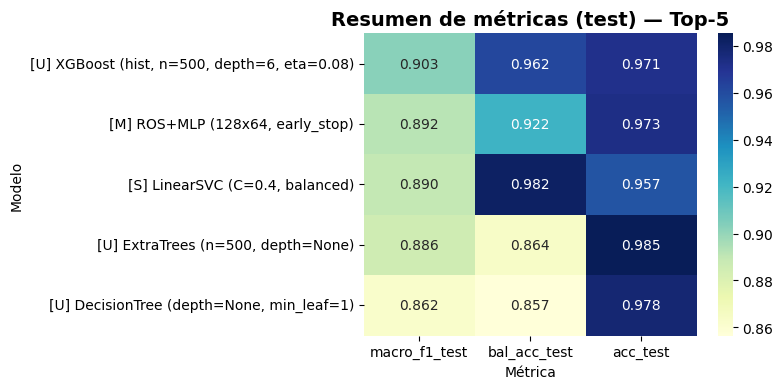

In [66]:
plt.figure(figsize=(8,4))
sns.heatmap(df_test_results.set_index("model"), annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("Resumen de métricas (test) — Top-5", fontsize=14, weight="bold")
plt.xlabel("Métrica"); plt.ylabel("Modelo")
plt.tight_layout()
plt.show()
